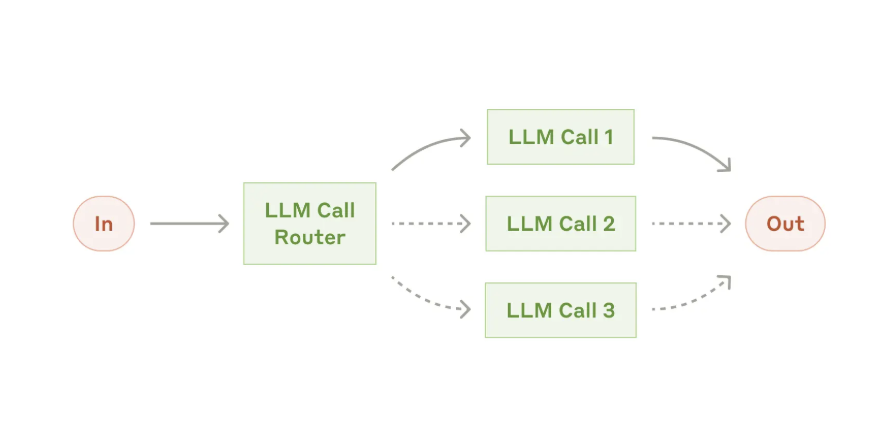

<a href="https://langchain-ai.github.io/langgraph/tutorials/workflows/">Source</a>

# 0.0. Configure

In [1]:
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

# 1.0. Import

In [4]:
from IPython.display import Image, display
from pydantic import BaseModel, Field

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

from typing_extensions import Literal
from langchain_core.messages import HumanMessage, SystemMessage

# 2.0. Hands-On

In [5]:
class State(TypedDict):
    input: str
    decision: str
    output: str

class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(None, description="The next step in the routing process")

In [6]:
llm = ChatOpenAI(model="gpt-4o")

In [7]:
router = llm.with_structured_output(Route)

In [8]:
def llm_call_1(state: State):
    """Write a Story"""

    result = llm.invoke(state["input"])

    return { "output": result.content }

def llm_call_2(state: State):
    """Write a Joke"""

    result = llm.invoke(state["input"])

    return { "output": result.content }

def llm_call_3(state: State):
    """Write a Poem"""

    result = llm.invoke(state["input"])

    return { "output": result.content }

In [9]:
def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    decidion = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return { "decision": decidion.step }

In [16]:
llm_call_router( { "input": "Tell me a history" } )

{'decision': 'story'}

In [15]:
llm_call_router( { "input": "Tell me something funny" } )

{'decision': 'joke'}

In [10]:
def route_decision(state: State):
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"

In [11]:
router_builder = StateGraph(State)

router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    }
)

router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

router_workflow = router_builder.compile()

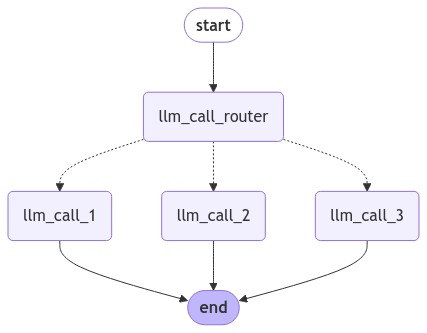

In [12]:
display(Image(router_workflow.get_graph().draw_mermaid_png()))

# 3.0. Testing

In [17]:
state = router_workflow.invoke({"input": "Write me a joke about cats"})

In [18]:
state["input"]

'Write me a joke about cats'

In [19]:
state["decision"]

'joke'

In [20]:
state["output"]

'Why did the cat sit on the computer?\n\nBecause it wanted to keep an eye on the mouse!'